In [24]:
import pandas as pd

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

from sklearn.cluster import KMeans

In [25]:
df=pd.read_csv("G:\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [26]:
df.shape

(200, 5)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [28]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


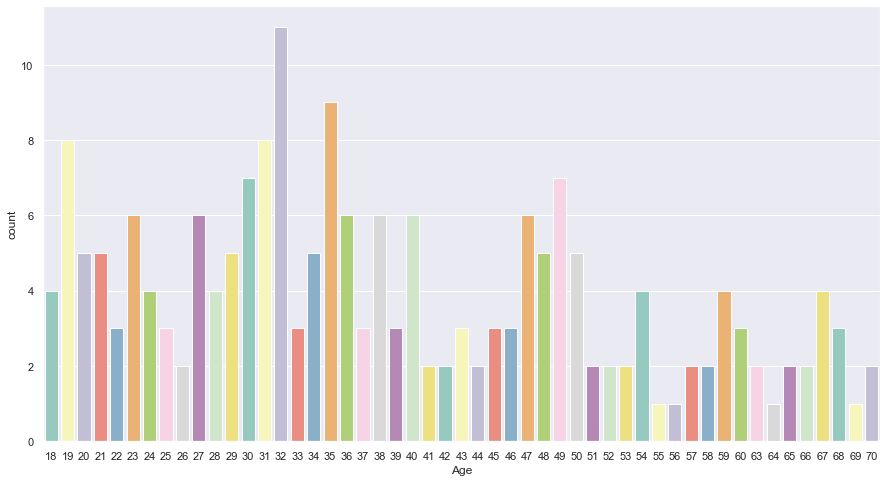

In [29]:
sns.set_theme(style="darkgrid")
plt.figure(figsize = (15,8))
sns.countplot(data = df, x = 'Age', palette="Set3")
plt.show()

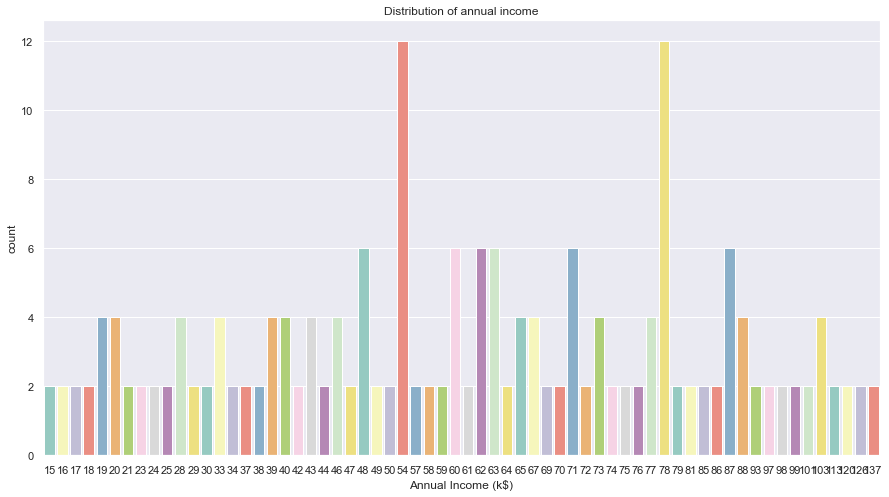

In [30]:
plt.figure(figsize = (15,8))
#x=df['Annual Income (k$)']
sns.countplot(x=df['Annual Income (k$)'],data=df,palette="Set3")
plt.title('Distribution of annual income')
plt.show()

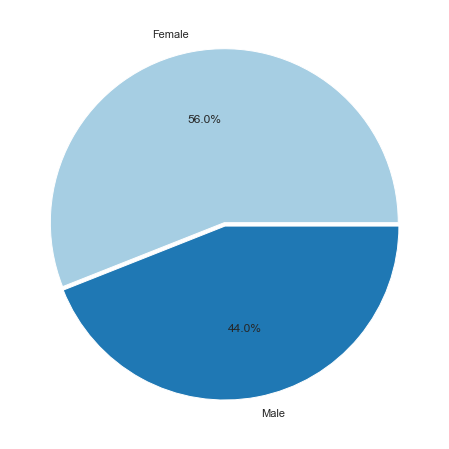

In [31]:
plt.figure(figsize=(8,8))
pal = sns.color_palette("Paired")
x=df.Gender.value_counts().index
y=df.Gender.value_counts().values.tolist()
df.Gender.value_counts()
plt.pie(y, labels=x, colors=pal, autopct='%1.1f%%',explode=[0.01 for i in df['Gender'].value_counts().index])
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
df.Gender = enc.fit_transform(df.Gender)
df.drop('CustomerID', axis = 1, inplace = True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [33]:
lst = []
for i in range(1,11):
    kmodel = KMeans(n_clusters = i, n_init = 15, max_iter = 500) 
    kmodel.fit(df)
    lst.append(kmodel.inertia_)
    
lst  

[308862.06000000006,
 212889.44245524294,
 143391.59236035674,
 104414.67534220174,
 75399.61541401486,
 58348.64136331505,
 51165.18423710792,
 44357.32664902663,
 40669.89814024847,
 37769.319989877076]

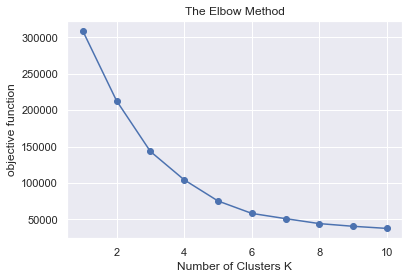

In [40]:
plt.plot(range(1,11), lst, marker = 'o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters K')
plt.ylabel('objective function')
plt.show()

In [35]:
kmodel = KMeans(n_clusters = 5)
kmodel.fit(df)
prediction = kmodel.predict(df)

In [36]:
df["clusters_ prediction"] = prediction
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters_ prediction
0,1,19,15,39,0
1,1,21,15,81,4
2,0,20,16,6,0
3,0,23,16,77,4
4,0,31,17,40,0


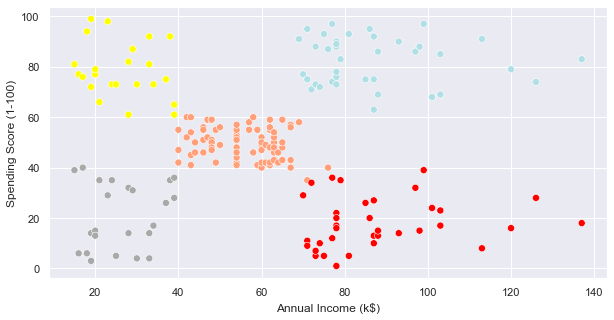

In [51]:
plt.figure(figsize=(10, 5))
color = np.array(['darkgray', 'lightsalmon', 'powderblue', 'red', 'yellow'])
sns.scatterplot(x = df['Annual Income (k$)'],
                y = df['Spending Score (1-100)'],
                c = color[kmodel.labels_],s =50)
plt.show()